In [1]:
# ENVIRONMENT
from enum import Enum
import random
import numpy as np


class State:
    def __init__(self, first_card: int, player_sum: int, terminal: bool = False):
        self.first_card = first_card
        self.player_sum = player_sum
        self.terminal = terminal

    def __repr__(self):
        return f"{self.first_card}, {self.player_sum}, {self.terminal}"

    def copy(self):
        return State(self.first_card, self.player_sum, self.terminal)


class Action(Enum):
    stick = "stick"
    hit = "hit"

    def __repr__(self) -> str:
        return self.name


class Color(Enum):
    black = "black"
    red = "red"


def initialise(verbose=False):
    dealer_number = random.randint(1, 10)
    player_number = random.randint(1, 10)
    state = State(first_card=dealer_number, player_sum=player_number)
    if verbose:
        print(
            f"Initial state: player sum: {state.player_sum}, dealer sum: {state.first_card}"
        )
    return state


def step(state: State, action: Action, verbose=False):

    next_state = state.copy()

    def draw():
        d_number = random.randint(1, 10)
        d_color = random.choices([Color.black, Color.red], weights=[2, 1])[0]
        return d_number, d_color

    if action == Action.hit:
        d_number, d_color = draw()
        next_state.player_sum += d_number if d_color == Color.black else -d_number

        if verbose:
            print(f"Player draws {d_number} {d_color}, sum is {next_state.player_sum}")

        if next_state.player_sum > 21 or next_state.player_sum < 1:
            next_state.terminal = True
            if verbose:
                print(f"Player loose the game!")
            return (next_state, -1)

        else:
            return (next_state, 0)

    if action == Action.stick:
        dealer_sum = state.first_card

        while dealer_sum < 17 and dealer_sum > 0:
            d_number, d_color = draw()
            dealer_sum += d_number if d_color == Color.black else -d_number

            if verbose:
                print(f"Dealer draws {d_number} {d_color}, sum is {dealer_sum}")

        if dealer_sum > 21 or dealer_sum < 1:
            next_state.terminal = True
            if verbose:
                print(f"Dealer loose the game!")
            return (next_state, 1)

        if dealer_sum > next_state.player_sum:
            next_state.terminal = True
            if verbose:
                print(f"Dealer win the game !")
            return (next_state, -1)

        if dealer_sum == next_state.player_sum:
            next_state.terminal = True
            if verbose:
                print(f"It's a draw !")
            return (next_state, 0)

        else:
            next_state.terminal = True
            if verbose:
                print(f"Player win !")
            return (next_state, 1)

In [2]:
# AGENT
from re import T
from typing import Tuple


def greedy_policy(state: State, value_hit, value_stick, verbose=False) -> Action:
    if verbose:
        print("Choose greedy")

    if value_hit > value_stick:
        return Action.hit
    if value_hit < value_stick:
        return Action.stick
    else:
        return random.choices([Action.hit, Action.stick])[0]


def random_policy(verbose=False) -> Action:
    if verbose:
        print("Choose random")
    choice = random.choices([Action.hit, Action.stick])[0]
    if verbose:
        print(choice)
    return choice


def e_greedy_policy(
    state: State, value_hit, value_stick, e: float, verbose=False
) -> Action:
    greedy_proba = 1 - e
    random_proba = e

    choice = random.choices([True, False], weights=[greedy_proba, random_proba])[0]

    return (
        greedy_policy(state, value_hit, value_stick, verbose)
        if choice
        else random_policy(verbose)
    )


def act(state: State, action: Action, verbose=False) -> tuple[State, int]:
    if action == Action.hit:
        return step(state, Action.hit, verbose)
    else:
        return step(state, Action.stick, verbose)


# VALUE FUNCTION
def initialise_value_table():
    m = np.zeros((21, 10, 2))
    return m


def max_q(table):
    return table.max(axis=2)


def mean_square_error(qvalue_table_1: np.ndarray, qvalue_table_2: np.ndarray):
    error_m = (qvalue_table_1 - qvalue_table_2) ** 2
    error = error_m.sum()
    return error

In [3]:
# TD0
def game_iteration_td(num: int, verbose=False, max_q_table=None):
    qvalue_table = initialise_value_table()
    q_n = np.zeros((21, 10, 2))
    s_n = np.zeros((21, 10))
    n_0 = 100
    error_list = []

    for k in range(num):
        state = initialise(verbose)
        action_t = None

        while not state.terminal:
            state_t = state.copy()

            if action_t is None:
                s_n[state_t.player_sum - 1, state_t.first_card - 1] += 1
                epsilon = n_0 / (
                    n_0 + s_n[state_t.player_sum - 1, state_t.first_card - 1]
                )
                value_hit = qvalue_table[state_t.player_sum - 1, state_t.first_card - 1, 1]
                value_stick = qvalue_table[state_t.player_sum - 1, state_t.first_card - 1, 0]
                action_t = e_greedy_policy(state_t, value_hit, value_stick, epsilon, verbose)

            state_t1, reward_t = act(state_t, action_t, verbose)

            qt_previous = qvalue_table[
                state_t.player_sum - 1,
                state_t.first_card - 1,
                1 if action_t == Action.hit else 0,
            ]

            if not state_t1.terminal:
                s_n[state_t1.player_sum - 1, state_t1.first_card - 1] += 1
                epsilon = n_0 / (
                    n_0 + s_n[state_t1.player_sum - 1, state_t1.first_card - 1]
                )
                value_hit = qvalue_table[state_t1.player_sum - 1, state_t1.first_card - 1, 1]
                value_stick = qvalue_table[state_t1.player_sum - 1, state_t1.first_card - 1, 0]
                action_t1 = e_greedy_policy(state_t1, value_hit, value_stick , epsilon, verbose)

                qt1_previous = qvalue_table[
                    state_t1.player_sum - 1,
                    state_t1.first_card - 1,
                    1 if action_t1 == Action.hit else 0,
                ]

            else:
                qt1_previous = 0

            qt_expected = reward_t + qt1_previous

            q_n[
                state_t.player_sum - 1,
                state_t.first_card - 1,
                1 if action_t == Action.hit else 0,
            ] += 1

            ratio = (
                1
                / q_n[
                    state_t.player_sum - 1,
                    state_t.first_card - 1,
                    1 if action_t == Action.hit else 0,
                ]
            )

            qt_new = qt_previous + ratio * (qt_expected - qt_previous)

            qvalue_table[
                state_t.player_sum - 1,
                state_t.first_card - 1,
                1 if action_t == Action.hit else 0,
            ] = qt_new

            state = state_t1

            if state_t1.terminal != True:
                action_t = action_t1
        
        if max_q_table is not None:
            error = mean_square_error(max_q(qvalue_table), max_q_table)
            error_list.append(error)

    return qvalue_table, error_list

In [4]:
# MONTECARLO
def update_value_table_montecarlo(table, history: [], n_q):
    expected_return = history[-1][1]

    for state, reward, action in history:
        state: State
        reward: int
        action: Action

        previous_value = table[
            state.player_sum - 1, state.first_card - 1, 1 if action == Action.hit else 0
        ]

        n_q[
            state.player_sum - 1, state.first_card - 1, 1 if action == Action.hit else 0
        ] += 1
        
        ratio = (
            1
            / n_q[
                state.player_sum - 1,
                state.first_card - 1,
                1 if action == Action.hit else 0,
            ]
        )

        add = ratio * (expected_return - previous_value)

        table[
            state.player_sum - 1, state.first_card - 1, 1 if action == Action.hit else 0
        ] += add
        
    return table


# GAME
def game_iteration_montecarlo(num: int, verbose=False, max_q_table=None):
    table = initialise_value_table()
    n_q = np.zeros((21, 10, 2))
    n_s = np.zeros((21, 10))
    error_list = []
    n_0 = 100

    for k in range(num):
        history = []
        state = initialise(verbose)
        while not state.terminal:
            old_state = state.copy()

            n_s[old_state.player_sum - 1, old_state.first_card - 1] += 1
            epsilon = n_0 / (
                n_0 + n_s[old_state.player_sum - 1, old_state.first_card - 1]
            )
            value_hit = table[old_state.player_sum - 1, old_state.first_card - 1, 1]
            value_stick = table[old_state.player_sum - 1, old_state.first_card - 1, 0]

            action = e_greedy_policy(state, value_hit, value_stick, epsilon, verbose)
            state, reward = act(state, action, verbose)
            history.append((old_state.copy(), reward, action))

        if verbose:
            print(history)
        table = update_value_table_montecarlo(table, history, n_q)
        
        if max_q_table is not None:
            error = mean_square_error(max_q(table), max_q_table)
            error_list.append(error)
        
    return table, error_list

In [5]:
# PLOT
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # activates 3D


def plot(table):
    # Create grid
    x = np.arange(1, 11)  # dealer showing
    y = np.arange(1, 22)  # player sum
    X, Y = np.meshgrid(x, y)

    # Some example value function Z
    Z = max_q(table)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_surface(
        X, Y, Z, rstride=1, cstride=1, linewidth=0, antialiased=False, color=None
    )
    ax.plot_wireframe(X, Y, Z)
    # ax.view_init(elev=20, azim=230)

    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")

    plt.show()

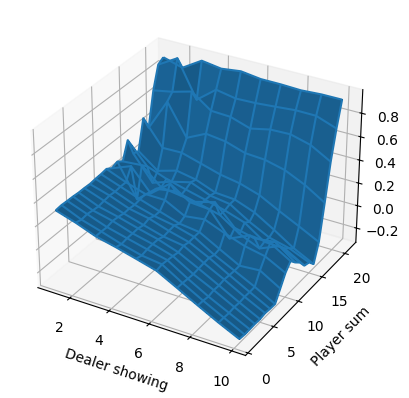

In [6]:
qvalue_table_m, error_list_m = game_iteration_montecarlo(3000000)
plot(qvalue_table_m)

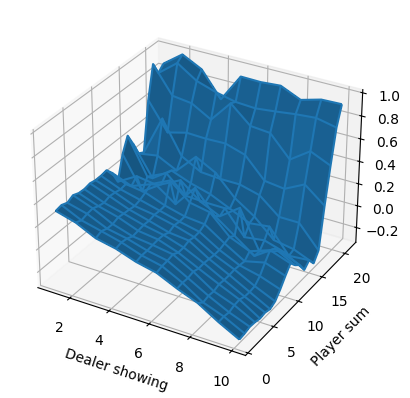

In [7]:
qvalue_table_td, error_list_td = game_iteration_td(1000000, max_q_table=max_q(qvalue_table_m))
plot(qvalue_table_td)

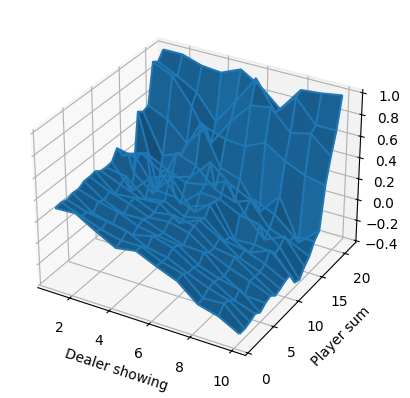

In [8]:
qvalue_table_m_10k, error_list_m_10k = game_iteration_montecarlo(100000, max_q_table=max_q(qvalue_table_m))
plot(qvalue_table_m_10k)

In [9]:
# TD(Y)
def game_iteration_tdy(num: int, gamma, lambd, verbose=False):
    error_list = []
    qvalue_table = initialise_value_table()
    q_n = np.zeros((21, 10, 2))
    s_n = np.zeros((21, 10))
    n_0 = 100

    ## GAME ITERATION
    for k in range(num):
        eligibility = np.zeros((21, 10, 2))
        state = initialise(verbose)
        action_t = None
        action_t1 = None


        ### STEP ITERATION
        while not state.terminal:
            #### UPDATE ELIGIBILITY
            state_t = state.copy()
            x_t = state_t.player_sum - 1
            y_t = state_t.first_card - 1

            eligibility *= gamma * lambd

            #### INIT FIRST ACTION
            if action_t is None:
                s_n[x_t, y_t] += 1
                epsilon = n_0 / (n_0 + s_n[x_t, y_t])
                value_hit = qvalue_table[x_t, y_t, 1]
                value_stick = qvalue_table[x_t, y_t, 0]
                action_t = e_greedy_policy(state_t, value_hit, value_stick, epsilon, verbose)

            z_t = 1 if action_t == Action.hit else 0

            eligibility[
                x_t,
                y_t,
                z_t,
            ] += 1

            #### AGENT ACT
            state_t1, reward_t = act(state_t, action_t, verbose)
            x_t1 = state_t1.player_sum - 1
            y_t1 = state_t1.first_card - 1

            #### COMPUTE QT AND QT1
            if not state_t1.terminal:
                s_n[x_t1, y_t1] += 1
                epsilon = n_0 / (n_0 + s_n[x_t1, y_t1])
                value_hit = qvalue_table[x_t1, y_t1, 1]
                value_stick = qvalue_table[x_t1, y_t1, 0]
                action_t1 = e_greedy_policy(state_t1, value_hit, value_stick, epsilon, verbose)

                z_t1 = 1 if action_t1 == Action.hit else 0

                qt1_previous = qvalue_table[
                    x_t1,
                    y_t1,
                    z_t1,
                ]

            else:
                qt1_previous = 0

            qt_previous = qvalue_table[
                x_t,
                y_t,
                z_t,
            ]

            q_n[
                x_t,
                y_t,
                z_t,
            ] += 1

            #### UPDATE ALL STATE
            qt_expected = reward_t + (gamma * qt1_previous)
            error_theta = qt_expected - qt_previous

            learning_rate_matrix = np.zeros_like(qvalue_table)
            nonzero_mask = q_n > 0
            learning_rate_matrix[nonzero_mask] = 1 / q_n[nonzero_mask]

            qvalue_table += eligibility * (learning_rate_matrix * error_theta)

            #### UPDATE STATE AND ACTION FOR NEXT LOOP
            state = state_t1

            if state_t1.terminal != True:
                action_t = action_t1
                
        error = mean_square_error(max_q(qvalue_table), max_q(qvalue_table_m))
        error_list.append(error)

    return qvalue_table, error_list

Mean square error: 1.9525527100972004
Mean square error: 2.793645549296792
Mean square error: 2.7771423295712596
Mean square error: 2.3393652983835134
Mean square error: 2.161733834035045
Mean square error: 3.0830170852236707
Mean square error: 2.2032361381232213
Mean square error: 2.582042421763951
Mean square error: 1.9653982091102522
Mean square error: 2.442810759196666
Mean square error: 2.2813039816956366


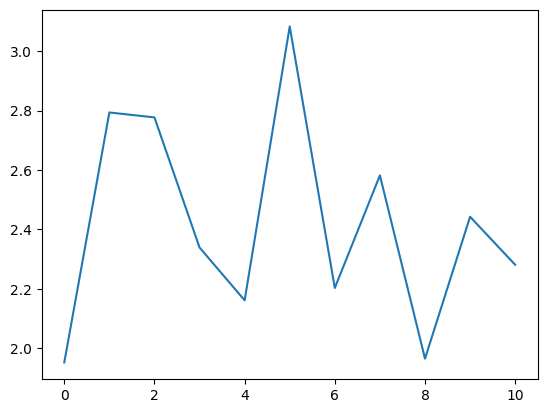

In [10]:
# MSE
def mean_square_error(qvalue_table_1: np.ndarray, qvalue_table_2: np.ndarray):
    error_m = (qvalue_table_1 - qvalue_table_2) ** 2
    error = error_m.sum()
    return error


error_per_lambda = []
error_list_per_lambda = []

for i in range(0, 11):
    lambd = i / 10
    qvalue_table_tdy, error_list = game_iteration_tdy(100000, 1, lambd)

    error_list_per_lambda.append(error_list)
    error = mean_square_error(max_q(qvalue_table_tdy), max_q(qvalue_table_m))
    error_per_lambda.append(error)
    
    print(f"Mean square error: {error}")

    
plt.plot(range(11), error_per_lambda)

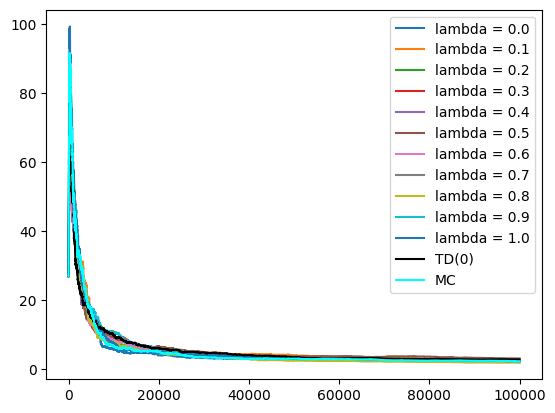

In [16]:
# LEARNING RATE
max_range = 100000

for i in range(0, 11):
    plt.plot(range(max_range), error_list_per_lambda[i][:max_range], label=f"lambda = {i / 10}")

plt.plot(range(max_range), error_list_td[:max_range], label="TD(0)", color="black")
plt.plot(range(max_range), error_list_m_10k[:max_range], label="MC", color="cyan")
plt.legend()
plt.show()


In [12]:
# FUNCTION APPROXIMATOR
DEALER_BOUND = [[1, 4], [4, 7], [7, 10]]
PLAYER_BOUND = [[1, 6], [4, 9], [7, 12], [10, 15], [13, 18], [16, 21]]
ACTION_BOUND = [Action.hit, Action.stick]


def feature_conversion(state: State, action: Action):
    feature = np.zeros((3, 6, 2))

    first_card = state.first_card
    player_sum = state.player_sum

    for x in range(3):
        for y in range(6):
            for z in range(2):
                dealer_lower = first_card >= DEALER_BOUND[x][0]
                dealer_upper = first_card <= DEALER_BOUND[x][1]
                player_lower = player_sum >= PLAYER_BOUND[y][0]
                player_upper = player_sum <= PLAYER_BOUND[y][1]
                action_feature = action == ACTION_BOUND[z]

                if all(
                    [
                        dealer_lower,
                        dealer_upper,
                        player_lower,
                        player_upper,
                        action_feature,
                    ]
                ):
                    feature[x, y, z] = 1

    return feature


def prediction(state: State, action: Action, weigths: np.array):
    feature = feature_conversion(state, action)

    prediction = (feature * weigths).sum()
    return prediction


class model_parameter:
    def __init__(self, alpha: float, gamma: float, delta: float):
        self.alpha = alpha
        self.gamma = gamma
        self.delta = delta


class sarsa_object:
    def __init__(
        self,
        state_t: State,
        action_t: Action,
        reward_t: int,
        state_t1: State,
        action_t1: Action,
    ):
        self.state_t = state_t
        self.action_t = action_t
        self.reward_t = reward_t
        self.state_t1 = state_t1
        self.action_t1 = action_t1


def update_weigths(
    sarsa: sarsa_object,
    eligibility_table: np.array,
    weigths: np.array,
    model_param: model_parameter,
) -> np.array:

    # COMPUTE DELTA UPDATE
    
    error_theta = (
        sarsa.reward_t + prediction(sarsa.state_t1, sarsa.action_t1, weigths)
    ) - prediction(sarsa.state_t, sarsa.action_t, weigths)
    update_delta = model_param.alpha * error_theta * eligibility_table

    # UPDATE WEIGTHS
    weigths += update_delta


def update_eligibility(
    model_param: model_parameter,
    eligibility_table: np.array,
    state: State,
    action: Action,
) -> np.array:
    features_x = feature_conversion(state, action)
    eligibility_table *= model_param.delta * model_param.gamma
    eligibility_table += features_x


def compute_value_table(weights: np.array) -> np.array:
    q_table = np.zeros((21, 10, 2))
    for psum in range(1, 22):
        for fcard in range(1, 11):
            for a in range(2):
                state = State(player_sum=psum, first_card=fcard, terminal=False)
                action = ACTION_BOUND[a]
                prediction_value = prediction(state, action, weights)
                q_table[psum - 1, fcard - 1, a] = prediction_value
    return q_table

In [13]:
# TD(Y) WITH FA
def game_iteration_tdyf(num: int, parameter: model_parameter, verbose=False):
    error_list = []
    weigths = np.zeros((3, 6, 2))

    ## GAME ITERATION
    for k in range(num):
        eligibility_table = np.zeros((3, 6, 2))
        state = initialise(verbose)
        action_t = None
        action_t1 = None
        
        if k > 1000:
            alpha = 0.005
        if k > 2000:
            alpha = 0.001
        if k > 3000:
            alpha = 1 / k
        else:
            alpha = 0.01
        parameter = model_parameter(alpha, parameter.gamma, parameter.delta)

        ### STEP ITERATION
        while not state.terminal:
            state_t = state.copy()

            #### INIT FIRST ACTION
            if action_t is None:
                value_hit = prediction(state_t, Action.hit, weigths)
                value_stick = prediction(state_t, Action.stick, weigths)
                action_t = e_greedy_policy(state_t, value_hit, value_stick, 0.05, verbose)

            update_eligibility(parameter, eligibility_table, state_t, action_t)

            #### AGENT ACT
            state_t1, reward_t = act(state_t, action_t, verbose)

            #### INIT SECOND ACTION
            if not state_t1.terminal:
                value_hit = prediction(state_t1, Action.hit, weigths)
                value_stick = prediction(state_t1, Action.stick, weigths)
                action_t1 = e_greedy_policy(state_t1, value_hit, value_stick, 0.05, verbose)

            #### UPDATE WEIGTHS
            sarsa_instance = sarsa_object(
                state_t, action_t, reward_t, state_t1, action_t1
            )
            update_weigths(sarsa_instance, eligibility_table, weigths, parameter)

            #### UPDATE STATE AND ACTION FOR NEXT LOOP
            state = state_t1

            if state_t1.terminal != True:
                action_t = action_t1
                
        qvalue_table = compute_value_table(weigths)
        error = mean_square_error(max_q(qvalue_table), max_q(qvalue_table_m))
        error_list.append(error)

    return qvalue_table, error_list, weigths

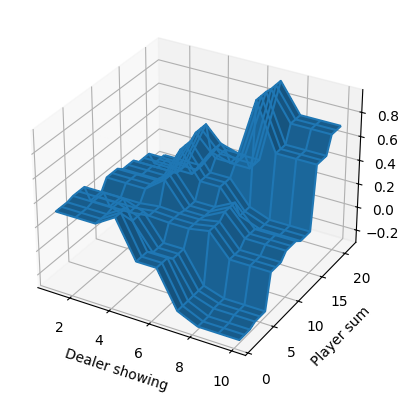

Mean square error: 17.913725798768898


In [17]:
parameter = model_parameter(alpha=0.01, gamma=1, delta=0.1)
qvalue_table_tdy, error_list_2, weigths = game_iteration_tdyf(3000, parameter)
plot(qvalue_table_tdy)
error = mean_square_error(max_q(qvalue_table_tdy), max_q(qvalue_table_m))  
print(f"Mean square error: {error}")

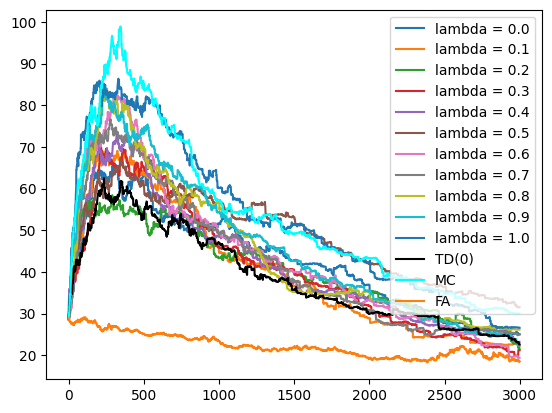

In [ ]:
# LEARNING RATE
max_range = 3000

for i in range(0, 11):
    plt.plot(range(max_range), error_list_per_lambda[i][:max_range], label=f"lambda = {i / 10}")

plt.plot(range(max_range), error_list_td[:max_range], label="TD(0)", color="black")
plt.plot(range(max_range), error_list_m_10k[:max_range], label="MC", color="cyan")
plt.plot(range(3000), error_list_2, label="FA")
plt.legend()
plt.show()

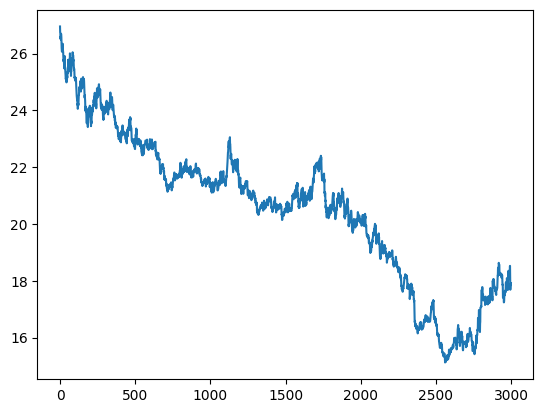

In [18]:
plt.plot(range(3000), error_list_2)

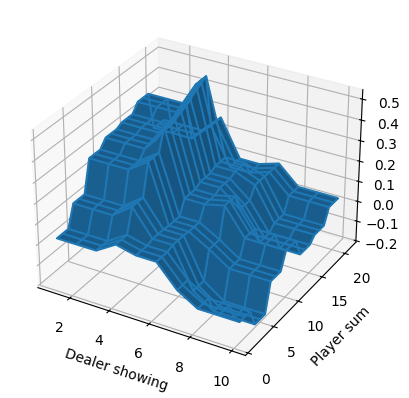

Mean square error: 18.388902339134653


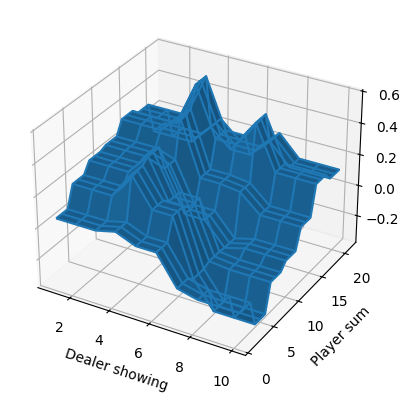

Mean square error: 17.828943757426213


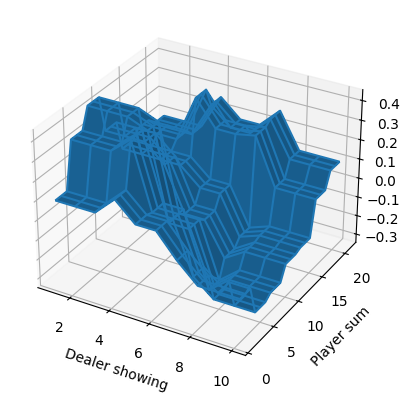

Mean square error: 17.84423113779386


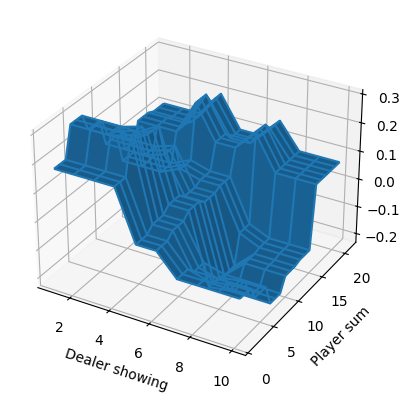

Mean square error: 18.77128599891367


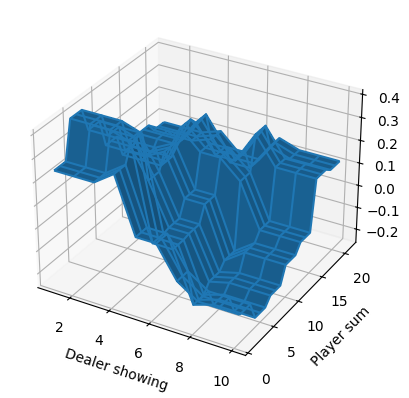

Mean square error: 19.67462828023696


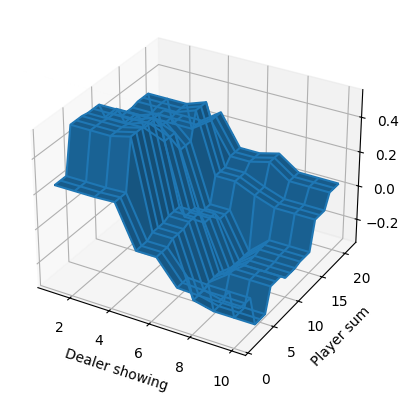

Mean square error: 20.579760478392082


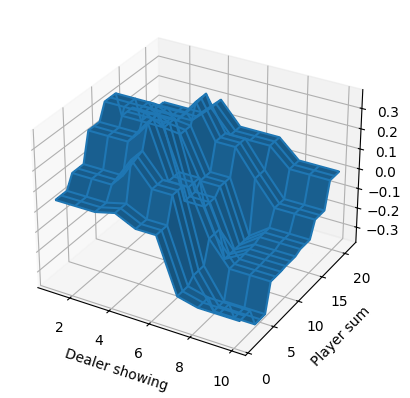

Mean square error: 20.63150202642343


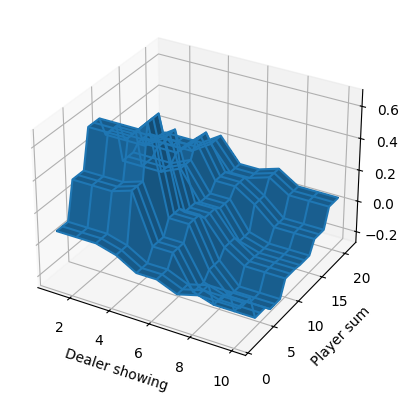

Mean square error: 20.177808912833424


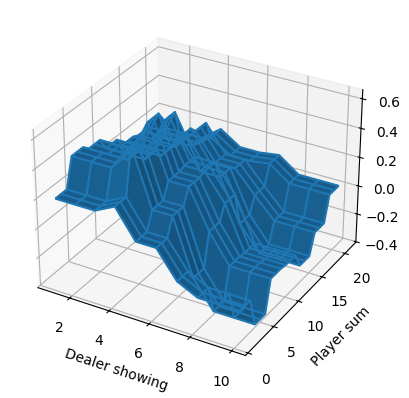

Mean square error: 21.487458829363995


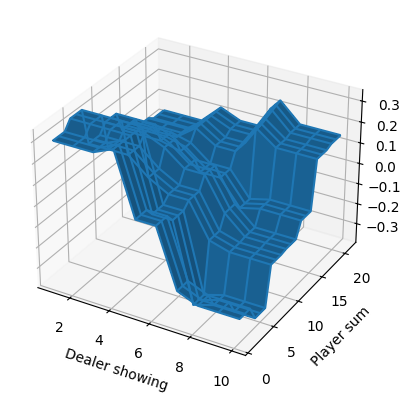

Mean square error: 19.37032973506591


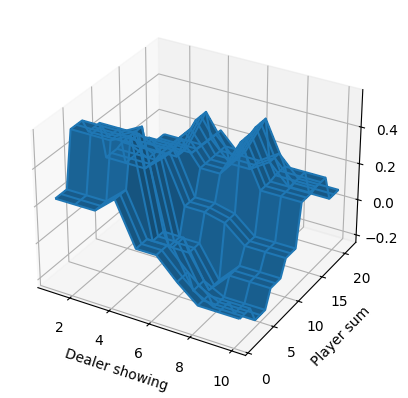

Mean square error: 21.74615173694306


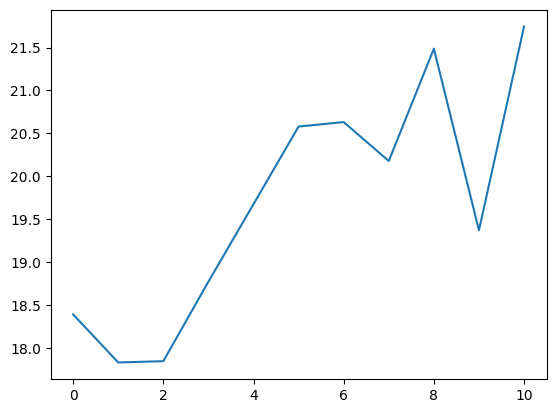

In [ ]:
error_per_lambda_fa = []
error_list_per_lambda_fa = []

for i in range(0, 11):
    lambd = i / 10
    parameter = model_parameter(alpha=0.01, gamma=1, delta=lambd)
    
    qvalue_table_tdy, error_list = game_iteration_tdyf(1000, parameter)
    plot(qvalue_table_tdy)

    error_list_per_lambda.append(error_list)
    error = mean_square_error(max_q(qvalue_table_tdy), max_q(qvalue_table_m))
    error_per_lambda.append(error)
    
    print(f"Mean square error: {error}")

    
plt.plot(range(11), error_per_lambda)